# 复用 `xa/` 准备流程和调参后的 XGBoost 做 xA 实验

这个 notebook 是 `enriched_xa_features_competition_events.ipynb` 的复制版，保留原 notebook 后半段的实验分析结构，只替换前面的建模设置：

- 数据加载和特征准备复用 `xa/xa_data.py` 与 `xa/model_contract.py`；
- XGBoost pipeline 复用 `xa/xgboost_model.py`；
- hyperparameters 使用 `xa/` 里通过 grid search + cross validation 找到的男组最佳 XGBoost 参数；
- notebook 内重新训练两个 fresh models：一个用 downsampled 男足数据，一个用女足非测试数据；
- 然后沿用原 notebook 的球员、pass profile、传球终点 grid 和 position bucket 分析。

注意：这里不加载已经训练好的 `.joblib` 模型，只复用最佳 hyperparameters。


## 1. Imports 和 constants

这些常量尽量和原 notebook 保持一致。女足 final test split 不再由 notebook 指定，而是由 `xa_data.load_xa_test_and_rest()` 使用 `xa/` 中唯一固定的数据划分策略。


In [1]:
import warnings
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
from mplsoccer import Pitch
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.base import clone

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd()
XA_CODE_DIR = PROJECT_ROOT / "xa"
if str(XA_CODE_DIR) not in sys.path:
    sys.path.insert(0, str(XA_CODE_DIR))

from xa_data import RANDOM_SEED, TARGET_COLUMN, load_xa_test_and_rest  # noqa: E402
from model_contract import make_feature_frame  # noqa: E402
import xgboost_model  # noqa: E402

DATA_DIR = Path("data")
CACHE_DIR = Path("vaep_data")
DATA_DIR.mkdir(exist_ok=True)
CACHE_DIR.mkdir(exist_ok=True)

MIN_PASSES_PER_PLAYER = 100
MIN_PASSES_PER_PASS_GROUP = 500
MIN_PLAYERS_FOR_BUCKET_SPEARMAN = 2

RESULTS_DIR = XA_CODE_DIR / "xa_all_models"
TRAINING_RESULTS_PATH = RESULTS_DIR / "xa_original_training_results.json"
if not TRAINING_RESULTS_PATH.exists():
    raise FileNotFoundError(TRAINING_RESULTS_PATH)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

print("ready")


ready


## 2. 使用 `xa_data` 加载 xA 数据

这里用 `xa/` 中可复用的数据准备代码，替代原 notebook 里手写的远程读取和特征构造流程。数据目录、随机种子和 women final test share 都固定在 `xa_data` 内部，notebook 不再传入这些参数，避免调参脚本和实验 notebook 出现不同 split。

StatsBomb event 坐标通常可以按“进攻方向从左到右”理解；这里不做盲目坐标翻转，而是在加载后用 shot-assist / goal-assist 传球的终点 `end_x` 做 sanity check：如果这些高价值传球大多落在高 `x` 区域，说明坐标方向符合后续 grid 图的解释。


In [2]:
bundle = load_xa_test_and_rest()

men_passes = bundle.men_rest.copy()
women_train_passes = bundle.women_rest.copy()
women_test_passes = bundle.women_test.copy()
women_passes = pd.concat([women_train_passes, women_test_passes], ignore_index=True)

split_summary = pd.DataFrame(bundle.split_summary).T


def attacking_direction_sanity_check(frame, label):
    """Check whether high-value passes end toward the high-x attacking goal."""
    rows = []
    for subset_label, subset in [
        ("shot_assist_passes", frame.loc[frame["assisted_shot_xg"].gt(0)]),
        ("goal_assist_passes", frame.loc[frame["is_goal_assist"].fillna(False).astype(bool)]),
    ]:
        rows.append(
            {
                "sample": label,
                "subset": subset_label,
                "rows": int(len(subset)),
                "median_end_x": float(subset["end_x"].median()) if len(subset) else np.nan,
                "share_end_x_ge_80": float(subset["end_x"].ge(80).mean()) if len(subset) else np.nan,
                "share_end_x_ge_102": float(subset["end_x"].ge(102).mean()) if len(subset) else np.nan,
                "min_end_x": float(subset["end_x"].min()) if len(subset) else np.nan,
                "max_end_x": float(subset["end_x"].max()) if len(subset) else np.nan,
            }
        )
    return rows

attacking_direction_check = pd.DataFrame(
    attacking_direction_sanity_check(men_passes, "men completed passes")
    + attacking_direction_sanity_check(women_train_passes, "women train completed passes")
    + attacking_direction_sanity_check(women_test_passes, "women test completed passes")
)

print("Split summary:")
display(split_summary)
print("Attacking-direction sanity check: high-value pass endpoints should mostly be high x.")
display(attacking_direction_check.round(4))


Split summary:


,rows,games,positives,prevalence
men_rest,1136687.0,1517.0,2596.0,0.002284
women_rest,489432.0,694.0,1310.0,0.002677
women_final_test,54832.0,77.0,150.0,0.002736


Attacking-direction sanity check: high-value pass endpoints should mostly be high x.


,sample,subset,rows,median_end_x,share_end_x_ge_80,share_end_x_ge_102,min_end_x,max_end_x
0,men completed passes,shot_assist_passes,27035,104.20,0.9320,0.5515,24.6,120.0
1,men completed passes,goal_assist_passes,2596,109.00,0.9700,0.7573,30.9,119.2
2,women train completed passes,shot_assist_passes,12274,105.20,0.9432,0.5906,32.2,120.0
3,women train completed passes,goal_assist_passes,1310,109.55,0.9771,0.7725,36.1,119.2
4,women test completed passes,shot_assist_passes,1416,105.70,0.9654,0.6052,19.8,119.2
5,women test completed passes,goal_assist_passes,150,109.05,0.9867,0.7133,62.7,117.7


## 3. input 数据预处理

和原 notebook 一样，先把男足训练集下采样到女足训练集规模。不同的是，特征构造改为复用 `xa/model_contract.py` 里的 `make_feature_frame`，确保和训练脚本使用同一套 feature schema。


In [3]:
downsample_size = len(women_train_passes)
if len(men_passes) < downsample_size:
    raise ValueError("Men pass sample is smaller than women train sample; cannot downsample as planned.")

men_downsampled_passes = men_passes.sample(
    n=downsample_size,
    random_state=RANDOM_SEED,
    replace=False,
).copy()

men_downsampled_features = make_feature_frame(men_downsampled_passes)
women_train_features = make_feature_frame(women_train_passes)
women_test_features = make_feature_frame(women_test_passes)

print("target column:", TARGET_COLUMN)
print("feature columns:", len(men_downsampled_features.columns))
print(
    "feature frame shapes | "
    f"men_downsampled={men_downsampled_features.shape} "
    f"women_train={women_train_features.shape} "
    f"women_test={women_test_features.shape}"
)


target column: target_goal_assist
feature columns: 51
feature frame shapes | men_downsampled=(489432, 51) women_train=(489432, 51) women_test=(54832, 51)


## 4. 训练 xA 模型并给同一批女足 test passes 打分

两个 fresh XGBoost pipelines 使用同一组男组最佳 hyperparameters：一个在 downsampled 男足数据上训练，另一个在女足非测试数据上训练。


In [4]:
training_results = json.loads(TRAINING_RESULTS_PATH.read_text(encoding="utf-8"))
BEST_MEN_XGBOOST_PARAMS = training_results["selected_candidates"]["xgboost"]["men"]["best_params"]

display(pd.Series(BEST_MEN_XGBOOST_PARAMS, name="value").to_frame())

xgb_spec = xgboost_model.get_model_spec(quick=False)


def train_xa_model(features, target, model_label):
    """Train one pass-level xA classifier with the tuned XGBoost hyperparameters."""
    model = clone(xgb_spec.estimator).set_params(**BEST_MEN_XGBOOST_PARAMS)
    model.fit(features, target.astype(int))
    print(f"[trained] {model_label}: rows={len(features):,} positives={int(target.sum()):,}")
    return model


def predict_xa(model, features):
    """Predict xA-like probability and clip to [0, 1]."""
    return np.clip(model.predict_proba(features)[:, 1], 0.0, 1.0)


men_downsampled_xa_model = train_xa_model(
    men_downsampled_features,
    men_downsampled_passes[TARGET_COLUMN],
    "men downsampled tuned XGBoost xA",
)
women_xa_model = train_xa_model(
    women_train_features,
    women_train_passes[TARGET_COLUMN],
    "women tuned XGBoost xA",
)

xa_predictions = women_test_passes.copy()
xa_predictions["men_downsampled_model_xa"] = predict_xa(men_downsampled_xa_model, women_test_features)
xa_predictions["women_model_xa"] = predict_xa(women_xa_model, women_test_features)
xa_predictions["xa_delta"] = xa_predictions["men_downsampled_model_xa"] - xa_predictions["women_model_xa"]

print("Training pass counts:")
print(f"- men downsampled: {len(men_downsampled_passes):,}")
print(f"- women train: {len(women_train_passes):,}")
print(f"- women test: {len(women_test_passes):,}")
print("Prediction sums:")
print(f"- men downsampled model: {xa_predictions['men_downsampled_model_xa'].sum():.2f}")
print(f"- women model: {xa_predictions['women_model_xa'].sum():.2f}")


,value
model__colsample_bytree,0.880
model__learning_rate,0.035
model__max_depth,4.000
model__min_child_weight,10.000
model__n_estimators,350.000
model__reg_alpha,0.200
model__reg_lambda,8.000
model__subsample,0.900


[trained] men downsampled tuned XGBoost xA: rows=489,432 positives=1,148
[trained] women tuned XGBoost xA: rows=489,432 positives=1,310
Training pass counts:
- men downsampled: 489,432
- women train: 489,432
- women test: 54,832
Prediction sums:
- men downsampled model: 157.47
- women model: 153.79


## 5. 球员位置、门将过滤和 Spearman helper

优先使用已有 position cache；如果没有，就从本 notebook 的女足 pass rows 里抽取球员位置。


In [5]:
POSITION_CACHE_CANDIDATES = [
    CACHE_DIR / "women_positions_competition_events_method.pkl",
    CACHE_DIR / "women_positions_statsbombpy_remote.pkl",
    CACHE_DIR / "women_pos.parquet",
]


def load_women_position_rows(fallback_passes=None):
    """Load cached women player-position observations, or use pass-row fallback."""
    for position_cache in POSITION_CACHE_CANDIDATES:
        if position_cache.exists():
            print(f"[cache] women positions: {position_cache}")
            if position_cache.suffix == ".parquet":
                positions = pd.read_parquet(position_cache).copy()
            else:
                positions = pd.read_pickle(position_cache).copy()
            break
    else:
        if fallback_passes is None:
            raise FileNotFoundError("No women position cache found and no fallback pass rows were provided.")
        print("[fallback] women positions from xA pass rows")
        positions = fallback_passes[["player_id", "position_name"]].copy()

    required_columns = {"player_id", "position_name"}
    missing_columns = required_columns.difference(positions.columns)
    if missing_columns:
        raise ValueError(f"Position cache missing columns: {sorted(missing_columns)}")

    positions = positions[list(required_columns)].dropna().copy()
    positions["player_id_key"] = pd.to_numeric(positions["player_id"], errors="coerce").astype("Int64")
    positions["position_name"] = positions["position_name"].astype(str)
    positions = positions.dropna(subset=["player_id_key", "position_name"])
    return positions


def build_primary_position_table(position_rows):
    """Choose the most frequent observed position for each player."""
    position_counts = (
        position_rows.groupby(["player_id_key", "position_name"])
        .size()
        .reset_index(name="position_observations")
        .sort_values(["player_id_key", "position_observations", "position_name"], ascending=[True, False, True])
    )

    return (
        position_counts.groupby("player_id_key", as_index=False)
        .first()
        .rename(columns={"position_name": "primary_position"})
    )


def bucket_position(position_name):
    """Map granular StatsBomb positions to broad tactical buckets."""
    position_name = str(position_name)

    if "Goalkeeper" in position_name:
        return "Goalkeeper"
    if "Center Back" in position_name:
        return "Center Back"
    if "Wing Back" in position_name or position_name in {"Left Back", "Right Back"}:
        return "Fullback / Wing Back"
    if "Defensive Midfield" in position_name:
        return "Defensive Midfield"
    if "Center Midfield" in position_name:
        return "Central Midfield"
    if "Attacking Midfield" in position_name:
        return "Attacking Midfield"
    if position_name in {"Left Midfield", "Right Midfield", "Left Wing", "Right Wing"}:
        return "Wide Midfielder / Winger"
    if "Center Forward" in position_name or position_name == "Striker":
        return "Forward"
    return "Other / Unknown"


def spearman_if_available(left, right, min_observations=2):
    """Return Spearman correlation when there are enough non-constant observations."""
    paired_values = pd.DataFrame({"left": left, "right": right}).dropna()
    if len(paired_values) < min_observations:
        return np.nan
    if paired_values["left"].nunique(dropna=True) < 2 or paired_values["right"].nunique(dropna=True) < 2:
        return np.nan
    return stats.spearmanr(paired_values["left"], paired_values["right"])[0]


women_position_rows = load_women_position_rows(women_passes)
primary_positions = build_primary_position_table(women_position_rows)
primary_positions["position_bucket"] = primary_positions["primary_position"].map(bucket_position)
goalkeeper_player_id_keys = set(
    primary_positions.loc[primary_positions["position_bucket"].eq("Goalkeeper"), "player_id_key"]
)

print("primary-position rows:", len(primary_positions))
print("goalkeepers identified:", len(goalkeeper_player_id_keys))


[cache] women positions: vaep_data\women_positions_competition_events_method.pkl
primary-position rows: 1241
goalkeepers identified: 1


## 6. 球员层面汇总：男足 xA vs 女足 xA

按球员把 pass-level xA 加总，比较 downsampled 男足训练模型和女足训练模型在同一批女足测试传球上的球员排序。


In [6]:
player_xa_comparison_all = (
    xa_predictions.groupby("player_id")
    .agg(
        player_name=("player_name", "first"),
        men_downsampled_xa=("men_downsampled_model_xa", "sum"),
        women_xa=("women_model_xa", "sum"),
        observed_xa=("assisted_shot_xg", "sum"),
        pass_count=("women_model_xa", "size"),
        shot_assist_count=("is_shot_assist", "sum"),
        goal_assist_count=("is_goal_assist", "sum"),
    )
    .reset_index()
)

player_xa_comparison_all["player_id_key"] = pd.to_numeric(
    player_xa_comparison_all["player_id"],
    errors="coerce",
).astype("Int64")

player_xa_comparison_all = player_xa_comparison_all.merge(
    primary_positions,
    on="player_id_key",
    how="left",
)
player_xa_comparison_all["primary_position"] = player_xa_comparison_all["primary_position"].fillna("Unknown")
player_xa_comparison_all["position_bucket"] = player_xa_comparison_all["position_bucket"].fillna("Other / Unknown")
player_xa_comparison_all["xa_delta"] = (
    player_xa_comparison_all["men_downsampled_xa"] - player_xa_comparison_all["women_xa"]
)
player_xa_comparison_all["abs_xa_delta"] = player_xa_comparison_all["xa_delta"].abs()

player_xa_comparison = player_xa_comparison_all[
    (player_xa_comparison_all["pass_count"] >= MIN_PASSES_PER_PLAYER)
    & (~player_xa_comparison_all["player_id_key"].isin(goalkeeper_player_id_keys))
].copy()

rho_xa = spearman_if_available(
    player_xa_comparison["men_downsampled_xa"],
    player_xa_comparison["women_xa"],
)

print(f"xA | players={len(player_xa_comparison)} | Spearman downsampled men vs women={rho_xa:.3f}")
print("Total predicted xA on women test passes:")
print(f"- men downsampled model: {xa_predictions['men_downsampled_model_xa'].sum():.2f}")
print(f"- women model: {xa_predictions['women_model_xa'].sum():.2f}")
print(f"- realized assisted-shot xG label: {xa_predictions['assisted_shot_xg'].sum():.2f}")

display(
    player_xa_comparison.sort_values("abs_xa_delta", ascending=False)[
        [
            "player_id",
            "player_name",
            "primary_position",
            "position_bucket",
            "pass_count",
            "shot_assist_count",
            "observed_xa",
            "men_downsampled_xa",
            "women_xa",
            "xa_delta",
        ]
    ].head(20).round(4)
)


xA | players=133 | Spearman downsampled men vs women=0.971
Total predicted xA on women test passes:
- men downsampled model: 157.47
- women model: 153.79
- realized assisted-shot xG label: 145.79


,player_id,player_name,primary_position,position_bucket,pass_count,shot_assist_count,observed_xa,men_downsampled_xa,women_xa,xa_delta
126,10228,Manuela Giugliano,Right Center Midfield,Central Midfield,146,20,1.8970,2.3145,1.9511,0.3634
148,10392,Emilie Haavi,Left Wing,Wide Midfielder / Winger,109,10,1.5680,1.8850,1.5356,0.3495
202,15631,Niamh Charles,Left Back,Fullback / Wing Back,240,5,1.2046,1.6772,1.3936,0.2836
293,25693,Karen Araya,Left Defensive Midfield,Defensive Midfield,124,12,1.4793,1.4688,1.1925,0.2763
92,10097,Frederikke Thøgersen,Right Back,Fullback / Wing Back,153,7,0.7341,0.4687,0.7244,-0.2558
652,50153,Rocío Gálvez Luna,Right Center Back,Center Back,198,3,0.2338,0.1955,0.4436,-0.2481
192,15570,Chloe Kelly,Right Wing,Wide Midfielder / Winger,146,8,0.7736,1.2976,1.0540,0.2436
745,78072,Anna Patten,Right Center Back,Center Back,116,0,0.0000,0.3682,0.1306,0.2375
116,10192,Jordan Nobbs,Right Center Midfield,Central Midfield,101,4,0.2504,0.3443,0.5536,-0.2092
4,4642,Millie Bright,Right Center Back,Center Back,261,0,0.0000,0.1612,0.3549,-0.1937


## 7. 球员 scatter：同一批女足 test passes，不同训练数据模型

点越贴近对角线，说明男足训练模型和女足训练模型对球员 xA 总量 / 排名越接近。


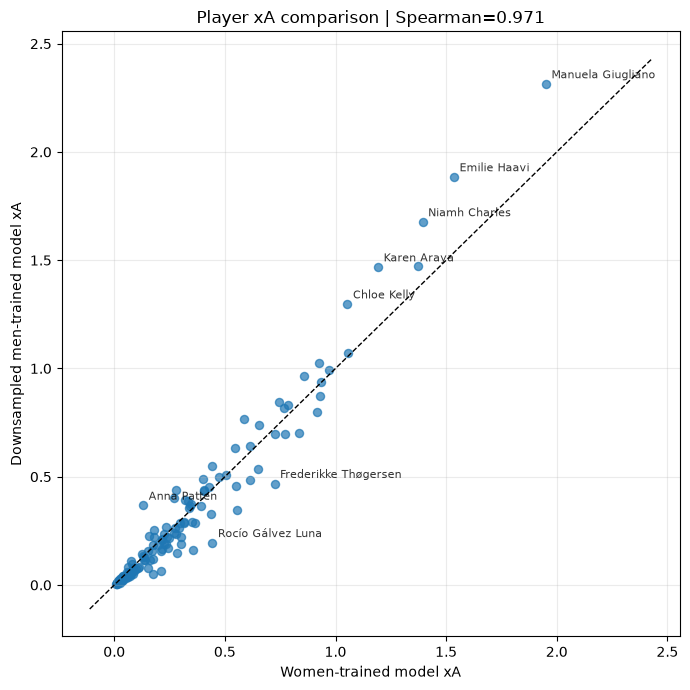

In [7]:
if player_xa_comparison.empty:
    print("No players passed the filtering threshold; lower MIN_PASSES_PER_PLAYER if needed.")
else:
    fig, axis = plt.subplots(figsize=(7, 7))

    axis.scatter(
        player_xa_comparison["women_xa"],
        player_xa_comparison["men_downsampled_xa"],
        alpha=0.70,
        s=34,
    )

    axis_min = min(player_xa_comparison["women_xa"].min(), player_xa_comparison["men_downsampled_xa"].min())
    axis_max = max(player_xa_comparison["women_xa"].max(), player_xa_comparison["men_downsampled_xa"].max())
    padding = (axis_max - axis_min) * 0.05 if axis_max > axis_min else 0.1
    axis.plot(
        [axis_min - padding, axis_max + padding],
        [axis_min - padding, axis_max + padding],
        linestyle="--",
        color="black",
        linewidth=1,
    )

    for _, row in player_xa_comparison.sort_values("abs_xa_delta", ascending=False).head(8).iterrows():
        label = row["player_name"] if row["player_name"] != "Unknown" else str(row["player_id"])
        axis.annotate(
            label,
            (row["women_xa"], row["men_downsampled_xa"]),
            fontsize=8,
            alpha=0.8,
            xytext=(4, 4),
            textcoords="offset points",
        )

    axis.set_xlabel("Women-trained model xA")
    axis.set_ylabel("Downsampled men-trained model xA")
    axis.set_title(f"Player xA comparison | Spearman={rho_xa:.3f}")
    axis.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


## 8. 模型预测和 realized xA label 的关系

这里的 realized label 是 `target_goal_assist` / `is_goal_assist`，非常稀疏；因此主要看整体尺度、相关性和误差，避免过度解读单脚传球层面的误差。


,source,passes,shot_assist_passes,total_predicted_xa,total_realized_xa,mean_predicted_xa,mae_vs_realized_xa,rmse_vs_realized_xa,mae_on_shot_assists,pearson_vs_realized_xa,spearman_vs_realized_xa
0,men_downsampled_model_xa,54832,1416,157.46943,145.79081,0.00287,0.00245,0.01717,0.05437,0.72568,0.25827
1,women_model_xa,54832,1416,153.78899,145.79081,0.00280,0.00248,0.01654,0.05413,0.74556,0.25714


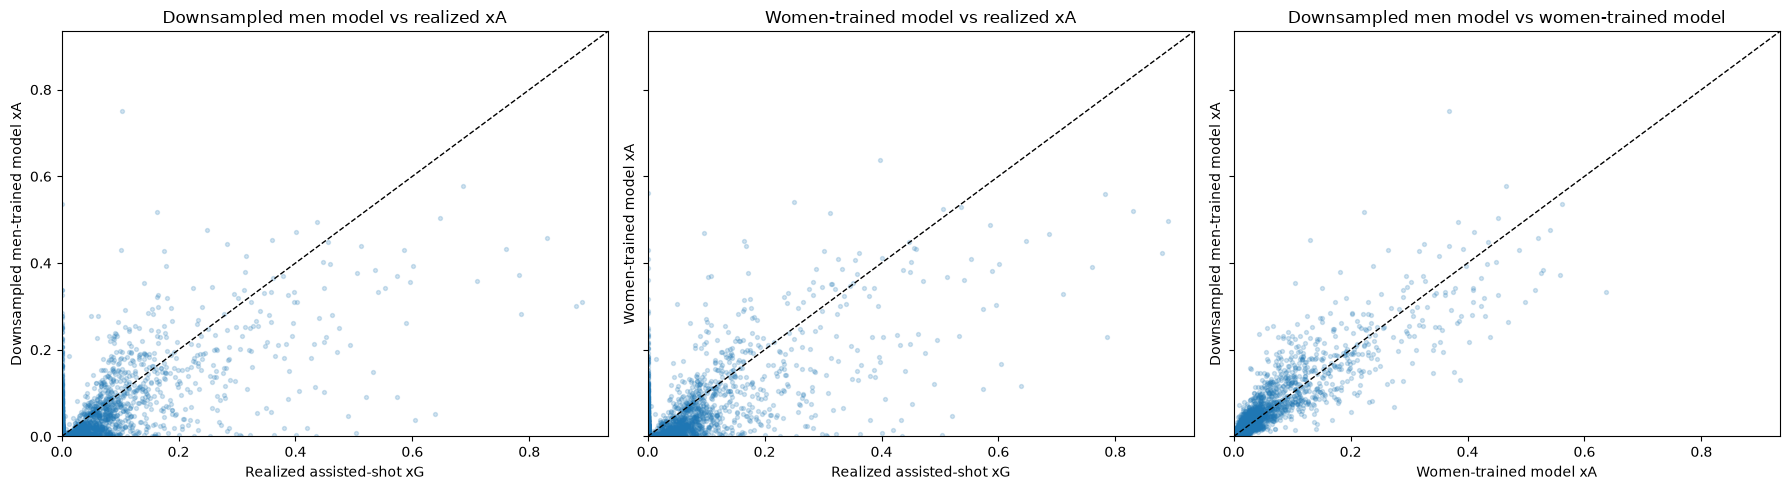

In [8]:
observed_xa = xa_predictions["assisted_shot_xg"].astype(float)
shot_assist_mask = observed_xa > 0

comparison_rows = []
for source_label, prediction_column in [
    ("men_downsampled_model_xa", "men_downsampled_model_xa"),
    ("women_model_xa", "women_model_xa"),
]:
    prediction = xa_predictions[prediction_column].astype(float)
    comparison_rows.append(
        {
            "source": source_label,
            "passes": len(prediction),
            "shot_assist_passes": int(shot_assist_mask.sum()),
            "total_predicted_xa": prediction.sum(),
            "total_realized_xa": observed_xa.sum(),
            "mean_predicted_xa": prediction.mean(),
            "mae_vs_realized_xa": np.mean(np.abs(prediction - observed_xa)),
            "rmse_vs_realized_xa": np.sqrt(np.mean((prediction - observed_xa) ** 2)),
            "mae_on_shot_assists": (
                np.mean(np.abs(prediction[shot_assist_mask] - observed_xa[shot_assist_mask]))
                if shot_assist_mask.any()
                else np.nan
            ),
            "pearson_vs_realized_xa": prediction.corr(observed_xa, method="pearson"),
            "spearman_vs_realized_xa": prediction.corr(observed_xa, method="spearman"),
        }
    )

model_vs_realized_xa = pd.DataFrame(comparison_rows)
display(model_vs_realized_xa.round(5))

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
scatter_specs = [
    (
        "assisted_shot_xg",
        "men_downsampled_model_xa",
        "Realized assisted-shot xG",
        "Downsampled men-trained model xA",
        "Downsampled men model vs realized xA",
    ),
    (
        "assisted_shot_xg",
        "women_model_xa",
        "Realized assisted-shot xG",
        "Women-trained model xA",
        "Women-trained model vs realized xA",
    ),
    (
        "women_model_xa",
        "men_downsampled_model_xa",
        "Women-trained model xA",
        "Downsampled men-trained model xA",
        "Downsampled men model vs women-trained model",
    ),
]

max_xa = xa_predictions[["assisted_shot_xg", "men_downsampled_model_xa", "women_model_xa"]].max().max()
axis_limit = min(1.0, max(0.02, max_xa * 1.05))

for axis, (x_column, y_column, x_label, y_label, title) in zip(axes, scatter_specs):
    axis.scatter(
        xa_predictions[x_column],
        xa_predictions[y_column],
        alpha=0.20,
        s=8,
    )
    axis.plot([0, axis_limit], [0, axis_limit], linestyle="--", color="black", linewidth=1)
    axis.set_title(title)
    axis.set_xlabel(x_label)
    axis.set_ylabel(y_label)
    axis.set_xlim(0, axis_limit)
    axis.set_ylim(0, axis_limit)

plt.tight_layout()
plt.show()


## 9. 按传球终点 grid 比较模型差异

这里把女足测试集传球按照终点位置落到 12x16 grid，观察哪些区域的 `men_downsampled_model_xa - women_model_xa` 更大。


In [9]:
XA_GRID_ROWS = 12
XA_GRID_COLS = 16
MIN_GRID_PASSES = 200
STATSBOMB_PITCH_LENGTH = 120.0
STATSBOMB_PITCH_WIDTH = 80.0


def add_xa_end_grid_columns(passes, rows=XA_GRID_ROWS, cols=XA_GRID_COLS):
    """Assign each pass to a grid cell based on end location."""
    passes = passes.copy()
    valid_coordinates = passes[["end_x", "end_y"]].notna().all(axis=1)
    passes = passes[valid_coordinates].copy()

    passes["grid_col"] = np.floor(passes["end_x"] / STATSBOMB_PITCH_LENGTH * cols).astype(int).clip(0, cols - 1)
    passes["grid_row"] = np.floor(passes["end_y"] / STATSBOMB_PITCH_WIDTH * rows).astype(int).clip(0, rows - 1)
    return passes


def summarize_xa_delta_by_end_grid(passes, rows=XA_GRID_ROWS, cols=XA_GRID_COLS):
    """Summarize pass-level xA deltas by pass end-location grid."""
    passes_with_grid = add_xa_end_grid_columns(passes, rows=rows, cols=cols)
    passes_with_grid["xa_delta"] = passes_with_grid["men_downsampled_model_xa"] - passes_with_grid["women_model_xa"]

    all_cells = pd.MultiIndex.from_product(
        [range(rows), range(cols)],
        names=["grid_row", "grid_col"],
    ).to_frame(index=False)

    grid_summary = (
        passes_with_grid.groupby(["grid_row", "grid_col"])
        .agg(
            pass_count=("xa_delta", "size"),
            observed_xa=("assisted_shot_xg", "sum"),
            men_downsampled_xa=("men_downsampled_model_xa", "sum"),
            women_xa=("women_model_xa", "sum"),
            aggregate_xa_delta=("xa_delta", "sum"),
            mean_xa_delta=("xa_delta", "mean"),
            median_xa_delta=("xa_delta", "median"),
            mean_women_xa=("women_model_xa", "mean"),
            mean_men_downsampled_xa=("men_downsampled_model_xa", "mean"),
        )
        .reset_index()
    )

    grid_summary = all_cells.merge(grid_summary, on=["grid_row", "grid_col"], how="left")
    count_columns = ["pass_count"]
    sum_columns = ["observed_xa", "men_downsampled_xa", "women_xa", "aggregate_xa_delta"]
    grid_summary[count_columns + sum_columns] = grid_summary[count_columns + sum_columns].fillna(0)
    return passes_with_grid, grid_summary


xa_grid_predictions, xa_grid_delta_summary = summarize_xa_delta_by_end_grid(xa_predictions)
valid_grid_mask = xa_grid_delta_summary["pass_count"] >= MIN_GRID_PASSES

print("Grid delta definition: men_downsampled_model_xa - women_model_xa")
print(f"women test passes assigned to grid: {len(xa_grid_predictions):,} of {len(xa_predictions):,}")
print(f"non-empty grid cells: {(xa_grid_delta_summary.pass_count > 0).sum()} of {len(xa_grid_delta_summary)}")
print(f"grid cells with at least {MIN_GRID_PASSES} passes: {valid_grid_mask.sum()} of {len(xa_grid_delta_summary)}")

print("\nLargest absolute aggregate deltas by pass end grid:")
display(
    xa_grid_delta_summary[valid_grid_mask]
    .assign(abs_aggregate_delta=lambda frame: frame["aggregate_xa_delta"].abs())
    .sort_values("abs_aggregate_delta", ascending=False)
    .head(20)
    .round(5)
)


Grid delta definition: men_downsampled_model_xa - women_model_xa
women test passes assigned to grid: 54,832 of 54,832
non-empty grid cells: 192 of 192
grid cells with at least 200 passes: 135 of 192

Largest absolute aggregate deltas by pass end grid:


,grid_row,grid_col,pass_count,observed_xa,men_downsampled_xa,women_xa,aggregate_xa_delta,mean_xa_delta,median_xa_delta,mean_women_xa,mean_men_downsampled_xa,abs_aggregate_delta
94,5,14,219,18.59418,23.943501,19.084089,4.85941,0.02219,0.01932,0.08714,0.10933,4.85941
110,6,14,227,17.85628,22.572100,19.492760,3.07934,0.01357,0.01086,0.08587,0.09944,3.07934
107,6,11,209,1.17103,0.528320,0.901220,-0.37290,-0.00178,-0.00066,0.00431,0.00253,0.37290
156,9,12,280,0.29862,0.373070,0.705150,-0.33209,-0.00119,-0.00059,0.00252,0.00133,0.33209
59,3,11,261,0.43700,0.481330,0.811300,-0.32997,-0.00126,-0.00042,0.00311,0.00184,0.32997
43,2,11,300,0.17269,0.293800,0.564610,-0.27081,-0.00090,-0.00016,0.00188,0.00098,0.27081
123,7,11,207,1.13405,0.380100,0.640490,-0.26039,-0.00126,-0.00051,0.00309,0.00184,0.26039
44,2,12,239,0.54984,0.412220,0.658070,-0.24585,-0.00103,-0.00035,0.00275,0.00172,0.24585
155,9,11,306,0.30722,0.239010,0.465590,-0.22658,-0.00074,-0.00034,0.00152,0.00078,0.22658
139,8,11,279,0.36414,0.451260,0.619370,-0.16811,-0.00060,-0.00052,0.00222,0.00162,0.16811


## 10. 传球终点 grid visualization

左图看女足测试集传球终点分布，右图看每个终点区域的平均模型差异。


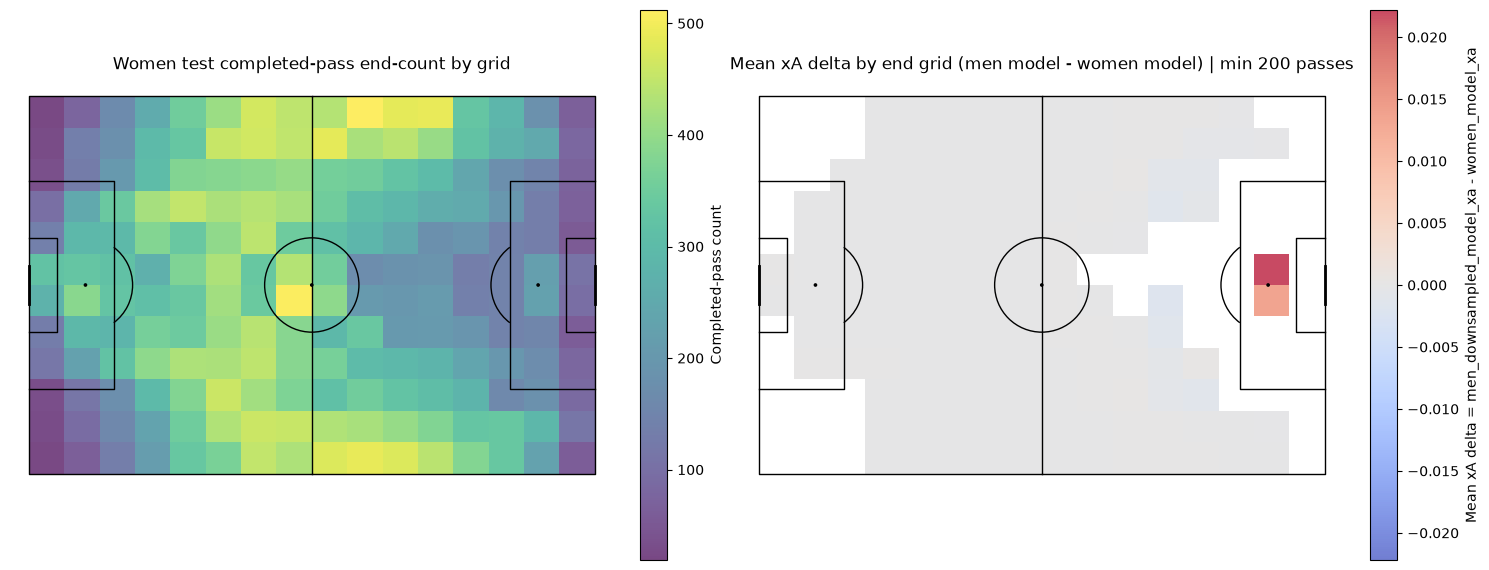

In [10]:
def grid_metric_matrix(grid_summary, metric, rows=XA_GRID_ROWS, cols=XA_GRID_COLS, min_passes=None):
    """Convert long grid summary into a rows x cols matrix."""
    matrix = np.full((rows, cols), np.nan)
    for _, row in grid_summary.iterrows():
        if min_passes is not None and row["pass_count"] < min_passes:
            continue
        matrix[int(row["grid_row"]), int(row["grid_col"])] = row[metric]
    return matrix


def plot_xa_grid_heatmap(axis, grid_summary, metric, title, cmap="viridis", center_zero=False, min_passes=None):
    """Draw one pitch heatmap from a grid metric."""
    pitch = Pitch(pitch_type="statsbomb", pitch_color="white", line_color="black", linewidth=1)
    pitch.draw(ax=axis)

    matrix = grid_metric_matrix(grid_summary, metric, min_passes=min_passes)
    if np.all(np.isnan(matrix)):
        axis.set_title(title + " (no valid cells)")
        return None

    if center_zero:
        value_limit = np.nanmax(np.abs(matrix))
        value_limit = value_limit if value_limit > 0 else 1e-6
        vmin, vmax = -value_limit, value_limit
    else:
        vmin, vmax = np.nanmin(matrix), np.nanmax(matrix)

    image = axis.imshow(
        matrix,
        extent=(0, STATSBOMB_PITCH_LENGTH, STATSBOMB_PITCH_WIDTH, 0),
        origin="upper",
        cmap=cmap,
        alpha=0.72,
        vmin=vmin,
        vmax=vmax,
    )
    axis.set_title(title)
    return image


fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))
image_0 = plot_xa_grid_heatmap(
    axes[0],
    xa_grid_delta_summary,
    "pass_count",
    "Women test completed-pass end-count by grid",
    cmap="viridis",
)
image_1 = plot_xa_grid_heatmap(
    axes[1],
    xa_grid_delta_summary,
    "mean_xa_delta",
    f"Mean xA delta by end grid (men model - women model) | min {MIN_GRID_PASSES} passes",
    cmap="coolwarm",
    center_zero=True,
    min_passes=MIN_GRID_PASSES,
)

colorbar_labels = [
    "Completed-pass count",
    "Mean xA delta = men_downsampled_model_xa - women_model_xa",
]
for axis, image, colorbar_label in zip(axes, [image_0, image_1], colorbar_labels):
    if image is not None:
        colorbar = fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
        colorbar.set_label(colorbar_label)

plt.tight_layout()
plt.show()


## 11. 按 pass context / end zone 分析模型差异

xA 全部来自传球，所以这里按传球上下文、终点区域、传球高度等 pass profile 来看差异。



pass_context groups with at least 500 passes:


,pass_context,passes,shot_assist_passes,observed_xa,men_downsampled_xa,women_xa,aggregate_xa_delta,mean_xa_delta,median_xa_delta,mean_men_downsampled_xa,mean_women_xa
2,Open Play,27299,596,67.15098,74.140617,74.523956,-0.38333,-0.00001,-0.00000,0.00272,0.00273
4,Restart,5893,69,7.98089,7.055920,7.023250,0.03267,0.00001,-0.00001,0.00120,0.00119
5,Throw-in,13968,298,28.14875,30.105190,29.788799,0.31639,0.00002,-0.00001,0.00216,0.00213
1,Free Kick,6116,184,18.09644,20.775749,19.244471,1.53127,0.00025,-0.00000,0.00340,0.00315
0,Corner,1308,252,23.09070,24.378330,22.092840,2.28549,0.00175,-0.00000,0.01864,0.01689



end_zone groups with at least 500 passes:


,end_zone,passes,shot_assist_passes,observed_xa,men_downsampled_xa,women_xa,aggregate_xa_delta,mean_xa_delta,median_xa_delta,mean_men_downsampled_xa,mean_women_xa
2,Final Third Left,4630,132,6.27453,6.795640,8.773070,-1.97743,-0.00043,-0.00000,0.00147,0.00189
3,Final Third Right,4866,110,5.78559,5.579310,6.719960,-1.14065,-0.00023,-0.00003,0.00115,0.00138
1,Final Third Central,2033,291,21.03604,18.472160,18.758230,-0.28608,-0.00014,-0.00034,0.00909,0.00923
4,Middle Third,25364,47,2.39734,2.578920,2.760630,-0.18171,-0.00001,-0.00001,0.00010,0.00011
0,Defensive Third,15978,2,0.08235,0.284040,0.346800,-0.06276,-0.00000,-0.00000,0.00002,0.00002
5,Penalty Box,1961,834,110.21496,123.759369,116.430313,7.32906,0.00374,-0.00057,0.06311,0.05937



pass_height groups with at least 500 passes:


,pass_height,passes,shot_assist_passes,observed_xa,men_downsampled_xa,women_xa,aggregate_xa_delta,mean_xa_delta,median_xa_delta,mean_men_downsampled_xa,mean_women_xa
2,Low Pass,5980,132,16.72839,16.150320,16.519529,-0.36921,-0.00006,-0.00001,0.00270,0.00276
0,Ground Pass,42112,720,68.23998,75.492912,72.853081,2.63984,0.00006,-0.00000,0.00179,0.00173
1,High Pass,6740,564,60.82244,65.826202,64.416382,1.40981,0.00021,-0.00003,0.00977,0.00956



pass_outcome groups with at least 500 passes:


,pass_outcome,passes,shot_assist_passes,observed_xa,men_downsampled_xa,women_xa,aggregate_xa_delta,mean_xa_delta,median_xa_delta,mean_men_downsampled_xa,mean_women_xa
0,Complete,54832,1416,145.79081,157.469437,153.788986,3.68044,0.00007,-0.00001,0.00287,0.0028


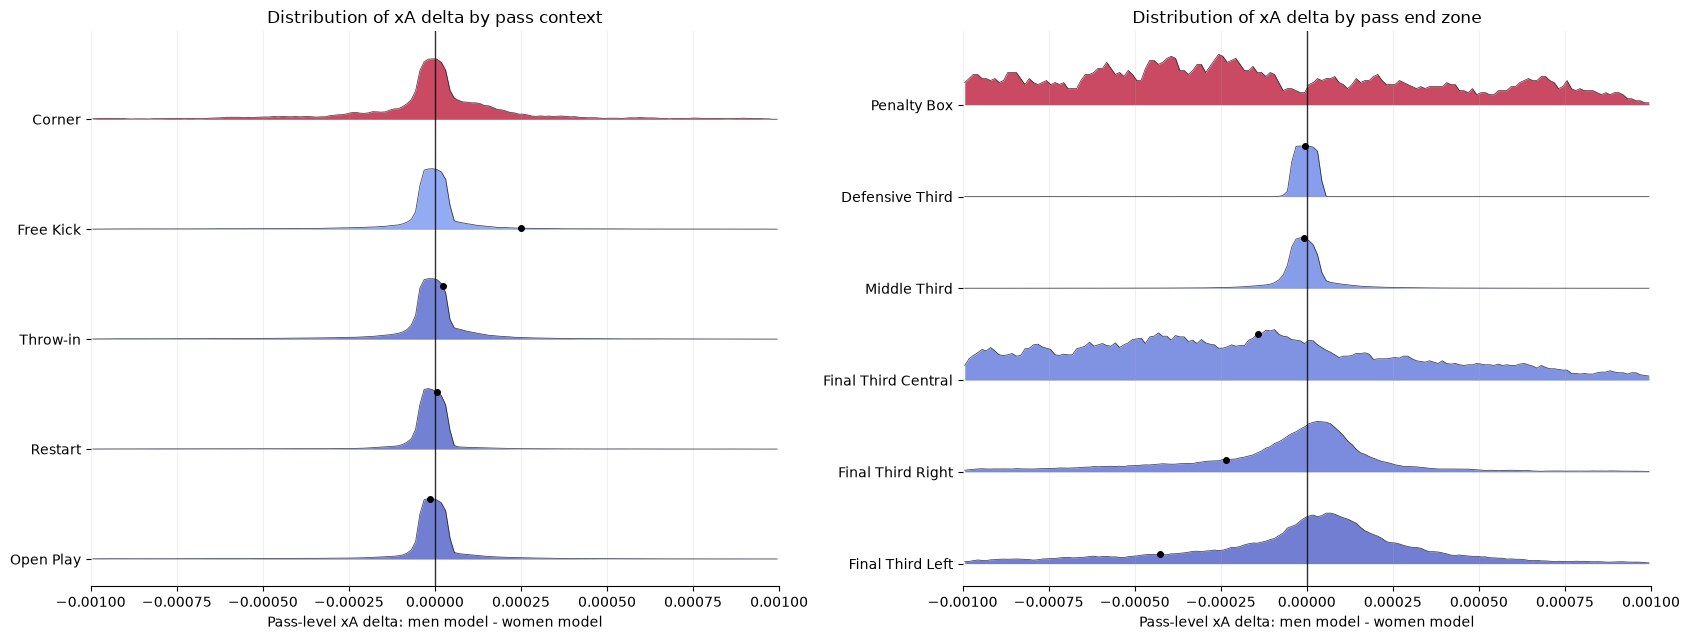

Note: ridgelines are smoothed histograms shown within [-0.001, +0.001] for readability. Each ridge is normalized to height 0.55, so shapes are comparable while group sizes are shown in the tables above.


In [11]:
def summarize_xa_by_group(group_column, min_passes=MIN_PASSES_PER_PASS_GROUP):
    """Summarize xA model differences for one categorical pass grouping."""
    summary = (
        xa_predictions.groupby(group_column)
        .agg(
            passes=("xa_delta", "size"),
            shot_assist_passes=("is_shot_assist", "sum"),
            observed_xa=("assisted_shot_xg", "sum"),
            men_downsampled_xa=("men_downsampled_model_xa", "sum"),
            women_xa=("women_model_xa", "sum"),
            aggregate_xa_delta=("xa_delta", "sum"),
            mean_xa_delta=("xa_delta", "mean"),
            median_xa_delta=("xa_delta", "median"),
            mean_men_downsampled_xa=("men_downsampled_model_xa", "mean"),
            mean_women_xa=("women_model_xa", "mean"),
        )
        .reset_index()
    )
    summary = summary[summary["passes"] >= min_passes].copy()
    return summary.sort_values("mean_xa_delta")


group_summaries = {}
for group_column in ["pass_context", "end_zone", "pass_height", "pass_outcome"]:
    summary = summarize_xa_by_group(group_column)
    group_summaries[group_column] = summary
    print(f"\n{group_column} groups with at least {MIN_PASSES_PER_PASS_GROUP:,} passes:")
    display(summary.round(5))


XA_GROUP_RIDGE_BINS = 160
XA_GROUP_DELTA_LIMIT = 0.001
XA_GROUP_SMOOTHING_WINDOW = 7
XA_GROUP_RIDGE_HEIGHT = 0.55
XA_GROUP_ROW_SPACING = 1.0


def plot_group_delta_ridgeline(axis, passes, summary, group_column, title):
    """Draw a ridgeline chart of pass-level xA deltas for one grouping."""
    if summary.empty:
        axis.set_title(title + " (no groups)")
        return

    group_order = summary.sort_values("mean_xa_delta")[group_column].tolist()
    distribution_rows = passes[passes[group_column].isin(group_order)].copy()

    x_min, x_max = -XA_GROUP_DELTA_LIMIT, XA_GROUP_DELTA_LIMIT

    bin_edges = np.linspace(x_min, x_max, XA_GROUP_RIDGE_BINS + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    smoothing_kernel = np.ones(XA_GROUP_SMOOTHING_WINDOW) / XA_GROUP_SMOOTHING_WINDOW

    cmap = plt.colormaps["coolwarm"]
    color_min = summary["mean_xa_delta"].min()
    color_max = summary["mean_xa_delta"].max()
    if np.isclose(color_min, color_max):
        color_min -= 0.001
        color_max += 0.001
    color_norm = plt.Normalize(color_min, color_max)

    y_positions = np.arange(len(group_order)) * XA_GROUP_ROW_SPACING

    for y_position, group_value in zip(y_positions, group_order):
        values = distribution_rows.loc[
            distribution_rows[group_column].eq(group_value),
            "xa_delta",
        ].dropna().to_numpy()

        if len(values) == 0:
            smoothed_density = np.zeros_like(bin_centers)
        else:
            histogram, _ = np.histogram(values, bins=bin_edges, density=True)
            smoothed_density = np.nan_to_num(np.convolve(histogram, smoothing_kernel, mode="same"))
            if smoothed_density.max() > 0:
                smoothed_density = smoothed_density / smoothed_density.max() * XA_GROUP_RIDGE_HEIGHT

        summary_row = summary[summary[group_column].eq(group_value)].iloc[0]
        ridge_color = cmap(color_norm(summary_row["mean_xa_delta"]))

        axis.fill_between(
            bin_centers,
            y_position,
            y_position + smoothed_density,
            color=ridge_color,
            alpha=0.72,
            linewidth=0,
        )
        axis.plot(
            bin_centers,
            y_position + smoothed_density,
            color="black",
            linewidth=0.55,
            alpha=0.75,
        )
        axis.hlines(y_position, x_min, x_max, color="gray", linewidth=0.35, alpha=0.35)

        mean_delta = summary_row["mean_xa_delta"]
        if x_min <= mean_delta <= x_max:
            mean_height = np.interp(mean_delta, bin_centers, smoothed_density)
            axis.scatter(mean_delta, y_position + mean_height, color="black", s=16, zorder=4)

    axis.axvline(0, color="black", linewidth=1.0, alpha=0.8)
    axis.set_yticks(y_positions)
    axis.set_yticklabels(group_order)
    axis.set_xlim(x_min, x_max)
    axis.set_ylim(y_positions[0] - 0.25, y_positions[-1] + XA_GROUP_RIDGE_HEIGHT + 0.25)
    axis.set_xlabel("Pass-level xA delta: men model - women model")
    axis.set_title(title)
    axis.grid(axis="x", alpha=0.18)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.spines["left"].set_visible(False)


fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
plot_group_delta_ridgeline(
    axes[0],
    xa_predictions,
    group_summaries["pass_context"],
    "pass_context",
    "Distribution of xA delta by pass context",
)
plot_group_delta_ridgeline(
    axes[1],
    xa_predictions,
    group_summaries["end_zone"],
    "end_zone",
    "Distribution of xA delta by pass end zone",
)
plt.tight_layout()
plt.show()

print(
    f"Note: ridgelines are smoothed histograms shown within [-{XA_GROUP_DELTA_LIMIT:.3f}, +{XA_GROUP_DELTA_LIMIT:.3f}] for readability. "
    f"Each ridge is normalized to height {XA_GROUP_RIDGE_HEIGHT}, so shapes are comparable while group sizes are shown in the tables above."
)


## 12. 按 position bucket 分析 xA 排名差异

这部分和原 notebook 的 position-bucket 分析保持一致：看每个位置组内的 Spearman、总 xA delta 和组内排名变化。


Position-bucket summary for women test-set players with at least 100 passes:


,position_bucket,players,passes,shot_assist_passes,observed_xa,spearman_men_vs_women_xa,aggregate_xa_delta,mean_xa_delta,median_xa_delta,mean_abs_xa_delta,mean_bucket_rank_delta,median_abs_bucket_rank_delta,max_abs_bucket_rank_delta
0,Center Back,51,8876,72,6.1964,0.9171,-0.9193,-0.0180,-0.0117,0.0443,0.0,2.0,22.0
1,Fullback / Wing Back,38,5291,99,11.0492,0.9807,-0.1935,-0.0051,-0.0095,0.0515,0.0,1.0,6.0
2,Defensive Midfield,23,3538,106,10.7378,0.9674,0.4911,0.0214,0.0123,0.0551,0.0,1.0,4.0
3,Central Midfield,7,880,46,3.9786,0.8929,0.0882,0.0126,-0.0123,0.1276,0.0,0.0,2.0
4,Other / Unknown,6,754,2,0.2237,0.9429,-0.0619,-0.0103,-0.0078,0.0103,0.0,0.0,1.0
5,Wide Midfielder / Winger,5,621,39,4.8787,1.0000,0.4948,0.0990,0.0465,0.1569,0.0,0.0,0.0
6,Attacking Midfield,2,290,6,0.5873,1.0000,0.2470,0.1235,0.1235,0.1235,0.0,0.0,0.0
7,Forward,1,120,7,0.7523,NaN,-0.1134,-0.1134,-0.1134,0.1134,0.0,0.0,0.0


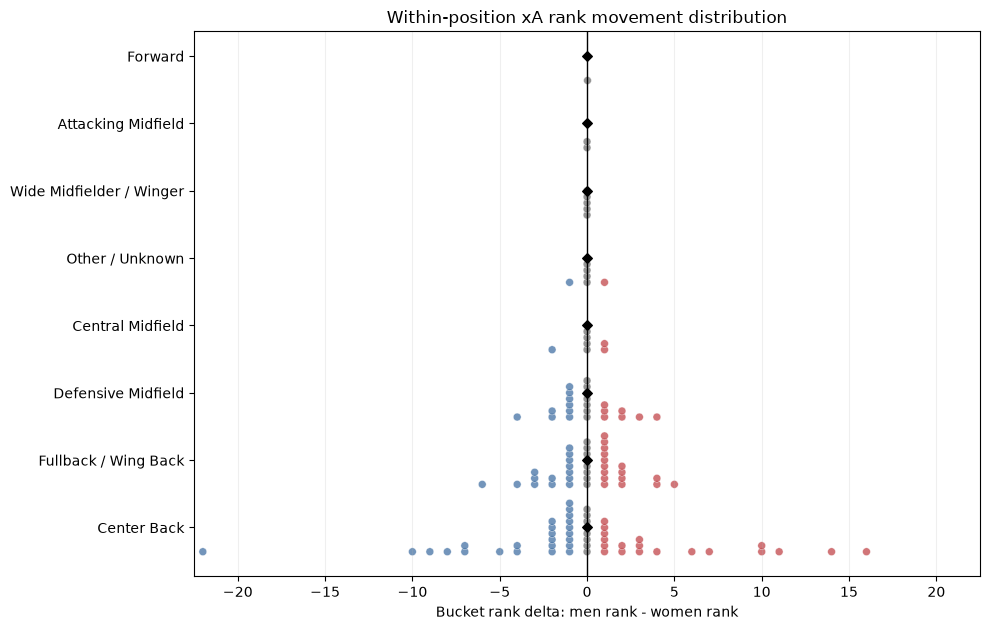


Players with largest within-bucket rank changes:


,player_id,player_name,primary_position,position_bucket,pass_count,observed_xa,men_downsampled_xa,women_xa,xa_delta,bucket_men_rank,bucket_women_rank,bucket_rank_delta
745,78072,Anna Patten,Right Center Back,Center Back,116,0.0000,0.3682,0.1306,0.2375,3.0,25.0,-22.0
58,5057,Kaleigh Kurtz,Right Center Back,Center Back,204,0.2332,0.0507,0.1745,-0.1238,33.0,17.0,16.0
971,323561,Emilie Bragstad,Center Back,Center Back,113,0.3588,0.0628,0.2100,-0.1471,29.0,15.0,14.0
4,4642,Millie Bright,Right Center Back,Center Back,261,0.0000,0.1612,0.3549,-0.1937,15.0,4.0,11.0
166,10666,Dominique Johanna Anna Petrone Janssen,Left Center Back,Center Back,127,0.0920,0.2256,0.1558,0.0698,9.0,19.0,-10.0
601,49918,Bibiane Schulze-Solano,Left Center Back,Center Back,234,0.2252,0.1460,0.2826,-0.1365,18.0,8.0,10.0
652,50153,Rocío Gálvez Luna,Right Center Back,Center Back,198,0.2338,0.1955,0.4436,-0.2481,12.0,2.0,10.0
392,32701,Caroline Pleidrup Gram,Left Center Back,Center Back,217,0.2365,0.2536,0.1805,0.0731,7.0,16.0,-9.0
277,25556,Kathellen Sousa Feitoza,Left Center Back,Center Back,166,0.0954,0.0847,0.0625,0.0222,25.0,33.0,-8.0
149,10395,Maren Nævdal Mjelde,Center Back,Center Back,186,0.1625,0.1453,0.1277,0.0176,19.0,26.0,-7.0


In [12]:
player_xa_by_position = player_xa_comparison.copy()

if player_xa_by_position.empty:
    print("No players available for position-bucket summary after filtering.")
else:
    player_xa_by_position["bucket_men_rank"] = player_xa_by_position.groupby("position_bucket")[
        "men_downsampled_xa"
    ].rank(ascending=False, method="min")
    player_xa_by_position["bucket_women_rank"] = player_xa_by_position.groupby("position_bucket")[
        "women_xa"
    ].rank(ascending=False, method="min")
    player_xa_by_position["bucket_rank_delta"] = (
        player_xa_by_position["bucket_men_rank"] - player_xa_by_position["bucket_women_rank"]
    )
    player_xa_by_position["abs_bucket_rank_delta"] = player_xa_by_position["bucket_rank_delta"].abs()

    bucket_summary_rows = []
    for position_bucket, bucket_players in player_xa_by_position.groupby("position_bucket"):
        bucket_summary_rows.append(
            {
                "position_bucket": position_bucket,
                "players": len(bucket_players),
                "passes": int(bucket_players["pass_count"].sum()),
                "shot_assist_passes": int(bucket_players["shot_assist_count"].sum()),
                "observed_xa": bucket_players["observed_xa"].sum(),
                "spearman_men_vs_women_xa": spearman_if_available(
                    bucket_players["men_downsampled_xa"],
                    bucket_players["women_xa"],
                    min_observations=MIN_PLAYERS_FOR_BUCKET_SPEARMAN,
                ),
                "aggregate_xa_delta": bucket_players["xa_delta"].sum(),
                "mean_xa_delta": bucket_players["xa_delta"].mean(),
                "median_xa_delta": bucket_players["xa_delta"].median(),
                "mean_abs_xa_delta": bucket_players["abs_xa_delta"].mean(),
                "mean_bucket_rank_delta": bucket_players["bucket_rank_delta"].mean(),
                "median_abs_bucket_rank_delta": bucket_players["abs_bucket_rank_delta"].median(),
                "max_abs_bucket_rank_delta": bucket_players["abs_bucket_rank_delta"].max(),
            }
        )

    position_bucket_xa_summary = (
        pd.DataFrame(bucket_summary_rows)
        .sort_values(["players", "passes"], ascending=False)
        .reset_index(drop=True)
    )

    print("Position-bucket summary for women test-set players with at least", MIN_PASSES_PER_PLAYER, "passes:")
    display(position_bucket_xa_summary.round(4))

    ordered_buckets = position_bucket_xa_summary.sort_values("players", ascending=False)["position_bucket"].tolist()
    rank_distribution_rows = player_xa_by_position.dropna(subset=["bucket_rank_delta"]).copy()
    RANK_STACK_HEIGHT = 0.72
    RANK_STACK_POINT_STEP = 0.09
    RANK_STACK_BOTTOM = -RANK_STACK_HEIGHT / 2

    fig, axis = plt.subplots(figsize=(10, max(6, 0.55 * len(ordered_buckets) + 2)))
    for y_index, position_bucket in enumerate(ordered_buckets):
        bucket_rank_values = rank_distribution_rows.loc[
            rank_distribution_rows["position_bucket"].eq(position_bucket),
            "bucket_rank_delta",
        ].to_numpy()
        if len(bucket_rank_values) == 0:
            continue

        y_offsets = np.zeros_like(bucket_rank_values, dtype=float)
        unique_rank_values, rank_group_ids = np.unique(bucket_rank_values, return_inverse=True)
        max_stack_size = max(np.bincount(rank_group_ids))
        stack_step = min(
            RANK_STACK_POINT_STEP,
            RANK_STACK_HEIGHT / max(max_stack_size - 1, 1),
        )
        for rank_group_id in range(len(unique_rank_values)):
            matching_points = np.flatnonzero(rank_group_ids == rank_group_id)
            y_offsets[matching_points] = RANK_STACK_BOTTOM + np.arange(len(matching_points)) * stack_step

        rank_colors = np.where(
            bucket_rank_values > 0,
            "#C44E52",
            np.where(bucket_rank_values < 0, "#4C78A8", "#777777"),
        )
        axis.scatter(
            bucket_rank_values,
            y_index + y_offsets,
            color=rank_colors,
            alpha=0.78,
            s=32,
            edgecolors="white",
            linewidths=0.35,
        )
        axis.scatter(
            np.median(bucket_rank_values),
            y_index,
            color="black",
            marker="D",
            s=24,
            zorder=4,
        )

    rank_limit = rank_distribution_rows["bucket_rank_delta"].abs().max()
    if pd.isna(rank_limit) or rank_limit == 0:
        rank_limit = 1
    axis.axvline(0, color="black", linewidth=1)
    axis.set_xlim(-rank_limit - 0.5, rank_limit + 0.5)
    axis.set_yticks(np.arange(len(ordered_buckets)))
    axis.set_yticklabels(ordered_buckets)
    axis.set_xlabel("Bucket rank delta: men rank - women rank")
    axis.set_title("Within-position xA rank movement distribution")
    axis.grid(axis="x", alpha=0.2)
    plt.tight_layout()
    plt.show()

    print("\nPlayers with largest within-bucket rank changes:")
    display(
        player_xa_by_position.sort_values("abs_bucket_rank_delta", ascending=False)[
            [
                "player_id",
                "player_name",
                "primary_position",
                "position_bucket",
                "pass_count",
                "observed_xa",
                "men_downsampled_xa",
                "women_xa",
                "xa_delta",
                "bucket_men_rank",
                "bucket_women_rank",
                "bucket_rank_delta",
            ]
        ]
        .head(25)
        .round(4)
    )


## 13. Read-out

这个 notebook 最后应该回答：

1. 在使用调参后 XGBoost hyperparameters 的情况下，男足训练的 xA 模型和女足训练的 xA 模型，在同一批女足 test passes 上给出的球员 xA 排名有多一致？
2. 两个模型的差异是否集中在某些 pass profile 上？
3. 差异是否集中在某些传球终点区域、传球上下文或 position bucket？

如果调参后的 xA Spearman 更接近 xG / xT，说明更强的 pass model 可能让跨性别迁移更稳定；如果仍然明显低于 xG / xT，或偏差集中在某些 pass profile 上，就说明助攻前传球的价值估计更容易受训练数据分布影响。
